<a href="https://colab.research.google.com/github/GimenesPaula/GimenesPaula/blob/main/Lan%C3%A7amentos_Vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas Phyton

In [1]:
!pip install unidecode wordcloud seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.3 MB/s eta 0:00:00


In [2]:
#Carrega Bibliotecas
import pandas as pd
import numpy as np
import re
from unidecode import unidecode
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import math


# Fazer Upload planilhas
1.   Lançamentos
2.   Inci
3.   Vendas

In [3]:
#Lançamentos
from google.colab import files
uploaded = files.upload()

Saving Lançamentos Jan Abr 2026.xlsx to Lançamentos Jan Abr 2026.xlsx


In [4]:
filename = next(iter(uploaded))

In [5]:
# INCI name produtos
from google.colab import files
inci = files.upload()

Saving inci_16_08.xlsx to inci_16_08.xlsx


In [6]:
filename2 = next(iter(inci))

In [7]:
#Vendas Distribuidores
from google.colab import files
dist = files.upload()

Saving Cópia de Focus Sales Report Q1 2026.xlsx to Cópia de Focus Sales Report Q1 2026.xlsx


In [10]:
filename4 = next(iter(dist))

# Função

In [147]:
# Função para limpar texto

def limpar(texto):
    if pd.isnull(texto):
        return []
    texto = unidecode(str(texto)).lower()
    texto = re.sub(r'\b\d{2,}\b', '', texto)
    texto = re.sub(r'[.,/\\-]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return [p for p in texto.split(' ') if p]

# Função para extrair chave representativa
def extrair_chave(palavras):
    if not palavras:
        return ''
    relevantes = [p for p in palavras if p not in PALAVRAS_IRRELEVANTES]
    if not relevantes:
        relevantes = palavras
    if len(relevantes) >= 2:
        return f"{relevantes[0]} {relevantes[1]}"
    return relevantes[0]

# Função para gerar chaves para DataFrame com fallback para valor bruto da coluna1
def gerar_chaves(df, coluna1, coluna2=None, coluna3=None):
    palavras1 = df[coluna1].apply(limpar)
    palavras2 = df[coluna2].apply(limpar) if coluna2 else pd.Series([[]] * len(df))
    palavras3 = df[coluna3].apply(limpar) if coluna3 else pd.Series([[]] * len(df))

    def chave_final(idx):
        for lista in [palavras1.iloc[idx], palavras2.iloc[idx], palavras3.iloc[idx]]:
            chave = extrair_chave(lista)
            if chave:
                return chave
        return str(df[coluna1].iloc[idx]).strip().lower()  # fallback para valor bruto da coluna1

    return pd.Series([chave_final(i) for i in range(len(df))], index=df.index)


In [148]:
def formatar_material(coluna):
    def extrair_codigo(texto):
        #Tenta extrair o padrão: 2+ letras + 1+ números
        match = re.search(r'\b([A-Za-z]{2,}\s*\d{1,})\b', texto)
        if match:
            return match.group(1).upper().strip()
    return coluna.apply(extrair_codigo)

In [149]:
#this checks if any combination of INCI as present in Ingredient
def verifica_ingrediente(formula,produto,material):
  quantidade = len(produto.difference(formula))
  if quantidade == 0:
    return material
  return None

In [150]:
#If last code is true, this returns the Descrição name
def procura_produtos(formula, produtos, materiais):
  formula = formula.copy()
  resultados = []
  for prod, mat in zip(produtos, materiais):
    resultado = verifica_ingrediente(formula, prod, mat)
    if resultado is not None:
      formula = formula.difference(prod) ## Para remover os ingredientes já encontrados numa nova busca.
      resultados.append(resultado)
  return resultados

In [151]:
# Função para sinalizar ingredientes do dictOTHERS
def sinaliza_ingredientes(x):
    ingredientes = set().union(*x)  # une todos os sets/listas de ingredientes do grupo
    encontrados = set()
    for ing in ingredientes:
        for palavra in dictOTHERS:
            if palavra.lower() in ing.lower():
                encontrados.add(ing)
    return ', '.join(sorted(encontrados))

In [152]:
#this code transpose data. Used when we bring each category and the number of lauches.
def transpor (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:[])

In [153]:

def to_set(x):
    s = set()
    for item in x:
        if isinstance(item, list):
            s.update(item)
        elif isinstance(item, str):
            s.add(item)
    return list(s)  # Retorna lista para compatibilidade com Excel


In [154]:
def transpor_2 (df, coluna, linha):
  for cat in df[coluna].unique():
    f = df[coluna] == cat
    df[cat] = df[f][linha]
    f = df[cat].isna()
    df.loc[f, cat] = df.loc[f, cat].apply(lambda x:x)

In [155]:
def extrair_estado(texto):
    if pd.isnull(texto):
        return None
    texto = str(texto).strip().lower()
    # Procura por sigla
    for sigla in estados:
        if re.search(r'\b' + re.escape(sigla.lower()) + r'\b', texto):
            return sigla
    # Procura por nome do estado
    for nome, sigla in estados_nome_para_sigla.items():
        if nome in texto:
            return sigla
    return None

In [156]:

# Função para extrair ingredientes exclusivos por subcategoria
def ingredientes_exclusivos_por_categoria(df, categoria, coluna_ingredientes):
    df_cat = df[df['Categoria'].str.contains(categoria, case=False, na=False)]
    subcats = df_cat['Sub-Categoria'].dropna().unique()
    subcat_ingredientes = {}

    for subcat in subcats:
        formulas = df_cat[df_cat['Sub-Categoria'] == subcat][coluna_ingredientes].dropna()
        sets_ingredientes = [set(map(str.strip, ing.split(','))) for ing in formulas]
        comuns = set.intersection(*sets_ingredientes) if sets_ingredientes else set()
        todos = set().union(*sets_ingredientes)
        exclusivos = todos - comuns
        subcat_ingredientes[subcat] = exclusivos

    # Agrupa todos os exclusivos da categoria
    ingredientes_filtrados = set().union(*subcat_ingredientes.values())
    return ingredientes_filtrados

# Função para remover pigmentos (para Maquilagem)
def remover_pigmentos(ingredientes):
    pigmentos = ['mica', 'talc', 'titanium dioxide']
    return [ing for ing in ingredientes if not (
        'ci' in ing.lower() or
        any(pig in ing.lower() for pig in pigmentos)
    )]

# Função para gerar nuvem de palavras
def gerar_nuvem(ingredientes, categoria):
    texto = ', '.join(ingredientes)
    wordcloud = WordCloud(width=1000, height=600, background_color='white').generate(texto)
    plt.figure(figsize=(12, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Nuvem de Palavras - Ingredientes INCI exclusivos ({categoria})', fontsize=16)
    plt.savefig(f"nuvem_INCI_exclusivos_{categoria.lower()}.png")
    plt.show()


#Dicionarios

In [157]:
#Dicionários
PALAVRAS_IRRELEVANTES = {
    'industria', 'comercio', 'cosmetico', 'cosmeticos', 'tecnologia', 'ltda', 'me', 'eireli', 'sa', 'cia', 'comercial', 'ind', ' e ',
    'produtos', 'servicos', 'serviço', 'do', 'da', 'de', 'dos', 'das', 'the', 'group', 'grupo',
    'inc', 'corp', 'corporation', 'associados', 'associado', 'associacao', 'associação', 'holding', 'importadora',
    'exportadora', 'importacao', 'importação', 'exportacao', 'exportação', 'distribuidora', 'distribuidor', 'fabricacao',
    'fabricante', 'comerciante', 'comercio', 'comércio', 'comercial', 'empresa', 'sociedade', 'unipessoal',
    'aerosol', 'aerossol',
}


In [158]:
# Dicionário de siglas e nomes de estados
estados = {
    'AC': 'Acre', 'AL': 'Alagoas', 'AP': 'Amapá', 'AM': 'Amazonas', 'BA': 'Bahia', 'CE': 'Ceará',
    'DF': 'Distrito Federal', 'ES': 'Espírito Santo', 'GO': 'Goiás', 'MA': 'Maranhão', 'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul', 'MG': 'Minas Gerais', 'PA': 'Pará', 'PB': 'Paraíba', 'PR': 'Paraná',
    'PE': 'Pernambuco', 'PI': 'Piauí', 'RJ': 'Rio de Janeiro', 'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul', 'RO': 'Rondônia', 'RR': 'Roraima', 'SC': 'Santa Catarina',
    'SP': 'São Paulo', 'SE': 'Sergipe', 'TO': 'Tocantins'
}
# Inverte para buscar por nome também
estados_nome_para_sigla = {v.lower(): k for k, v in estados.items()}


In [159]:
#Dicionário Silicones geral
dictOTHERS = {'methicone':'1', 'Dimethicone':'1','methicone Crosspolymer':'1','methiconol':'1',
              'ylsiloxysilicate':'1', 'ylsilsesquioxane':'1', 'Disiloxane':'1', 'Silica':'1','siloxane':'1'}

In [160]:
#Dicionário de palavras a remover da coluna Ingredientes no Mintel
dictIng = {
    r'\s*and/or\s*': ',',
    r',\s*': ',',
    r'\s*,': ',',
    r'\s*\(and\)\s*': ','
}

# Análise Ferramenta de Vendas

In [161]:
data = '/content/'+filename4
df_sale = pd.read_excel(data)
pd.options.display.max_columns=None
df_sale.nunique()

,0
Distributor (subsidiary),1
WACKER Business Team Initials,1
WACKER Market Segment,0
WACKER Application,0
WACKER Material No.,63
WACKER Material Name,67
Customer No. (at distributor),0
Customer Name,1261
Corporate Group (of customer),0
Country code ship-to (of customer),1


In [162]:
# Prepara Relatório
# Limpa e padroniza a coluna 'Material'
df_sale['WACKER Material Name'] = formatar_material(df_sale['WACKER Material Name'].astype(str))
df_sale['Distributor (subsidiary)'] = df_sale['Distributor (subsidiary)'].astype(str)

# Padroniza fabricantes e distribuidores
df_sale['KeyManuf'] = gerar_chaves(df_sale, 'Customer Name')

# Preenche Estado com base na coluna de região inicialmente
df_sale['Estado'] = df_sale['Region (State/Province) ship-to (of customer)'].astype(str)

estado_por_keymanuf = (
    df_sale[df_sale['Estado'].notna() & (df_sale['Estado'] != '')]
    .groupby('KeyManuf')['Estado']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])
    .to_dict()
)

def preencher_estado(row):
    if pd.isna(row['Estado']) or row['Estado'] == '' or row['Estado'] == 'nan':
        return estado_por_keymanuf.get(row['KeyManuf'], 'XX')
    return row['Estado']

df_sale['Estado'] = df_sale.apply(preencher_estado, axis=1)

df_final = df_sale.groupby(['KeyManuf', 'Estado']).agg(
               Distributor_Set = ('Distributor (subsidiary)', set),
               Sales_Qnty_2025 = ('WACKER Material Name', lambda x: len({str(i).strip() for i in x if pd.notnull(i)})),
               Sales_Kg_2025 = ('Quantity actual period', 'sum'),
               Sales_2025 = ('WACKER Material Name', to_set),
               )
df_final.to_excel('Resumo_vendas.xlsx')
df_final.head()


,,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
KeyManuf,Estado,,,,
&co e,SP,{FOCUS QUIMICA},4,1461.5,"[EG 6000, EG 5, TMS 803, DM 5]"
2k,SC,{FOCUS QUIMICA},1,15.0,[GB 1020]
3fa,GO,{FOCUS QUIMICA},4,1291.0,"[OW 2100, EG 5, GB 1020, DM 0]"
a &,SC,{FOCUS QUIMICA},13,15481.0,"[PF 22, EG 5, DM 6010, DM 350, OW 2100, GB 703..."
a&s technologies,SP,{FOCUS QUIMICA},7,37782.0,"[DM 6010, OW 2100, AK 12500, DM 1000, DM 0, TM..."


# Análise Relatórios Lançamentos

In [163]:
#Carrega o banco de dados como tabela
data = '/content/'+filename
df_launches = pd.read_excel(data)
pd.options.display.max_columns = None
df_launches.nunique()

,0
Número do Produto,2038
Data de Publicação,83
Produto,1495
Marca,1358
Empresa,537
Categoria,3
Sub-Categoria,33
Descrição do Produto,2037
Preço por 100g/ml,1568
Preço em moeda local,924



🔍 Maquilagem — palavras removidas (top 10):
  vitis vinifera seed oil (1)
  iron oxide (ci 77491 (1)
  ci 77266 s03: caprylic/capric triglyceride (1)
  rice amino acids (1)
  ci 77007) highlighter: talc (1)
  citric acid (1)
  rosa canina fruit oil (1)
  ci 19140 (1)
  gossypium herbaceum seed oil (and) butyrospermum parkii butter (and) macadamia ternifolia seed oil (and) cocos nucifera fruit (and) chamomilla recutita flower (and) aloe barbadensis leaf (and) camellia sinensis leaf (and) cinnamomum zeylanicum bark (and) acorus calamus root (and) commiphora myrrha resin (and) olea europaea fruit oil (and) aqua (and) argania spinosa kernel oil (and) lecithin (and) polyglyceryl-3 diisostearate (and) glycerin (and) glyceryl stearate (1)
  may contain (ci 77499 (black 11) (1)


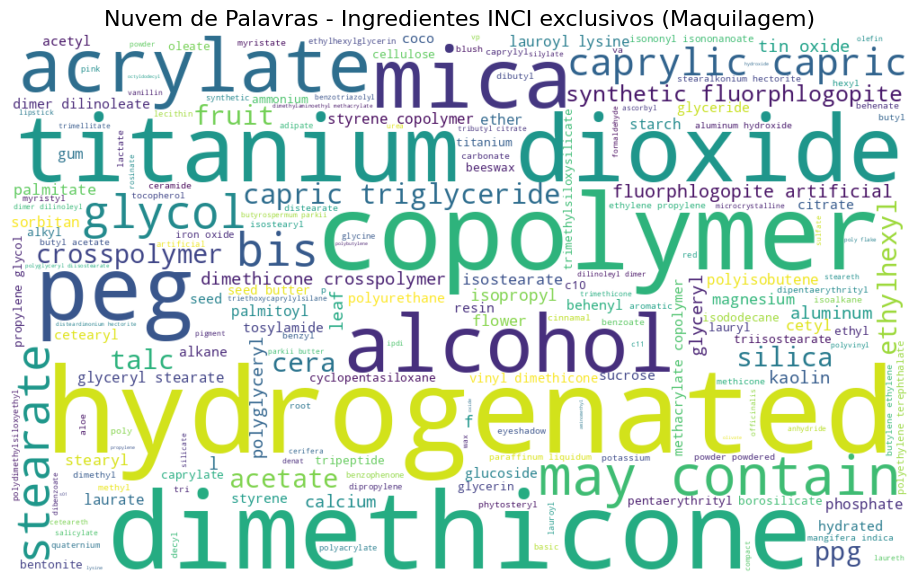


🔍 Cabelos — palavras removidas (top 10):
  kativa total plex bond builder concentrate: aqua (1)
  vitis vinifera seed oil (1)
  sodium salicylate (1)
  citrus bergamia peel oil expressed (expressed) (1)
  rice amino acids (1)
  parfum (parfum (1)
  citric acid (1)
  rosa canina fruit oil (1)
  ci 19140 (1)
  etidronic acid ultra repairing treatment: aqua (1)


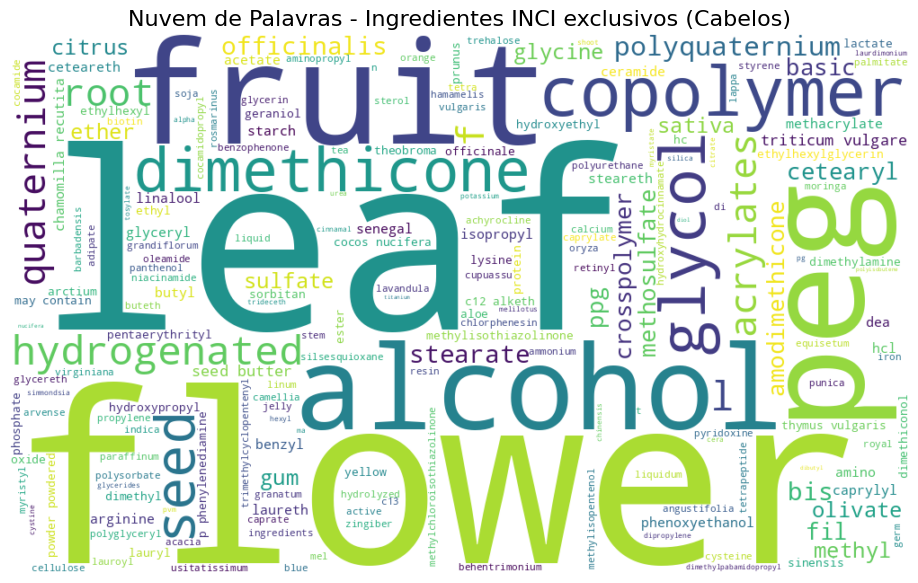


🔍 Pele — palavras removidas (top 10):
  rosa damascena flower water (2)
  propylene glycol (and) bht (and) ascorbyl palmitate (and) glyceryl stearate (and) citric acid (2)
  oryza sativa germ oil (1)
  vitis vinifera seed oil (1)
  ci 60725 (cosmetic colorant) (1)
  citric acid (1)
  ci 19140 (1)
  propylene glycol (and) bht (and) ascorbyl palmitate (and) glyceryl stearate (and) citric acid night cream: aqua (1)
  dehydroacetic acid (and) benzyl alcohol (and) ethylhexylglycerin (and) tocopheryl acetate (and) water (1)
  glyceryl acrylate/acrylic acid copolymer (1)


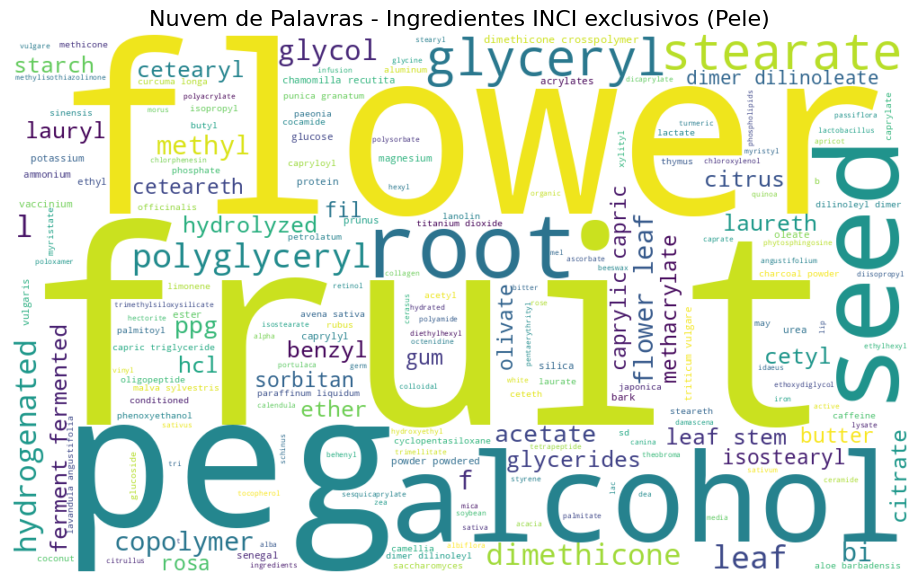

In [198]:
#Edita Coluna Ano
df_launches['Ano'] = pd.to_datetime(df_launches['Data de Publicação']).dt.year

def gerar_nuvem_categoria(
    df,
    categoria,
    coluna_ref,
    palavras_para_remover=None,
    percentual_exibicao=100,
    remover_pigmentos_flag=False,
    mostrar_removidos=True
):
    if palavras_para_remover is None:
        palavras_para_remover = []

    ingredientes = ingredientes_exclusivos_por_categoria(
        df, categoria, coluna_ref
    )

    ingredientes = normalizar_ingredientes(ingredientes)

    mantidos, removidos = classificar_ingredientes(
        ingredientes, palavras_para_remover
    )

    if remover_pigmentos_flag:
        mantidos = remover_pigmentos(mantidos)

    mantidos = limitar_por_percentual(
        mantidos, percentual_exibicao
    )

    if not mantidos:
        print(f"⚠️ Nenhuma palavra restante para '{categoria}'.")
        return

    if mostrar_removidos and removidos:
        print(f"\n🔍 {categoria} — palavras removidas (top 10):")
        for palavra, freq in Counter(removidos).most_common(10):
            print(f"  {palavra} ({freq})")

    gerar_nuvem(mantidos, categoria)

coluna_ref = "Ingredients (Standard form)"

# Maquiagem
gerar_nuvem_categoria(
    df_launches,
    categoria="Maquilagem",
    coluna_ref=coluna_ref,
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=100
)

# Cabelos
gerar_nuvem_categoria(
    df_launches,
    categoria="Cabelos",
    coluna_ref=coluna_ref,
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=40
)

# Pele
gerar_nuvem_categoria(
    df_launches,
    categoria="Pele",
    coluna_ref=coluna_ref,
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=35
)



🔍 Cabelos — palavras removidas (top 10):
  kativa total plex bond builder concentrate: aqua (1)
  vitis vinifera seed oil (1)
  sodium salicylate (1)
  citrus bergamia peel oil expressed (expressed) (1)
  rice amino acids (1)
  parfum (parfum (1)
  citric acid (1)
  rosa canina fruit oil (1)
  ci 19140 (1)
  etidronic acid ultra repairing treatment: aqua (1)


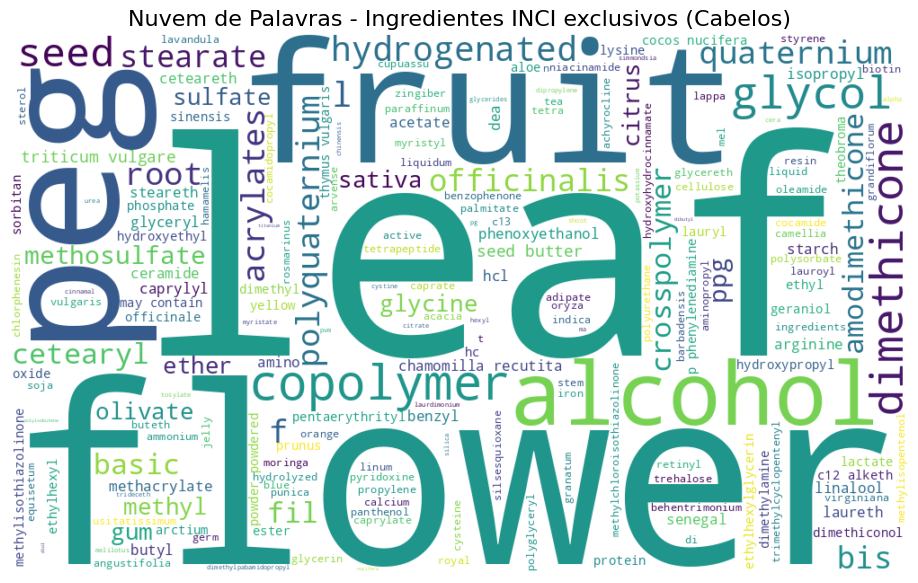

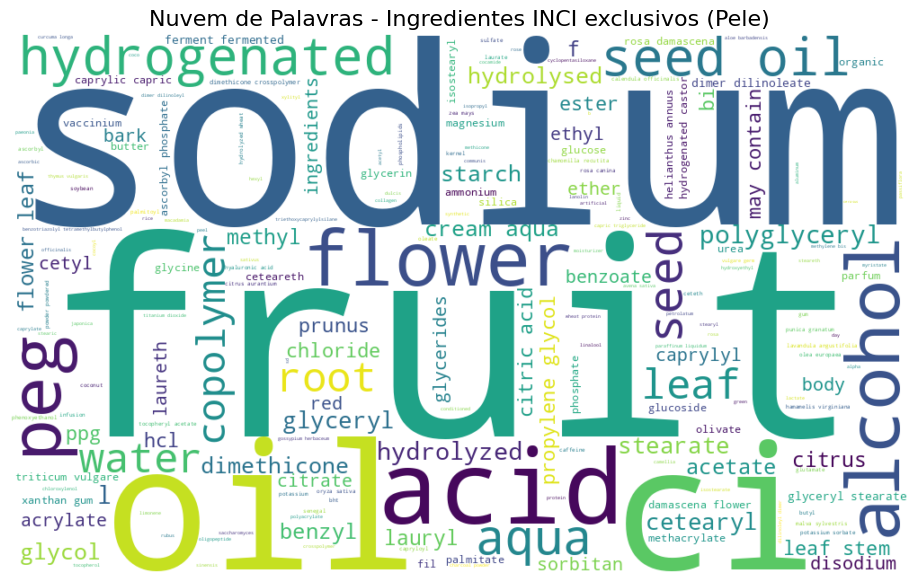

⚠️ Nenhuma palavra restante para 'Maquiagem'.


In [192]:
coluna_ref = "Ingredients (Standard form)"

# Cabelos
gerar_nuvem_categoria(
    df_launches,
    categoria="Cabelos",
    coluna_ref=coluna_ref,
    palavras_para_remover=filtros_usuario,
    percentual_exibicao=40
)

# Pele
gerar_nuvem_categoria(
    df_launches,
    categoria="Pele",
    coluna_ref=coluna_ref,
    percentual_exibicao=35
)

# Maquiagem
gerar_nuvem_categoria(
    df_launches,
    categoria="Maquiagem",
    coluna_ref=coluna_ref,
    percentual_exibicao=50,
    remover_pigmentos_flag=True
)

##Upload INCI

In [170]:
data = '/content/'+filename2
df_inci = pd.read_excel(data)
pd.options.display.max_columns=None
df_inci.nunique()

,0
Produto,51
Ingrediente,50
Prioridade,3


## Contém Silicone?

In [171]:
df_launches['Silicone'] = df_launches['Ingredients (Standard form)'].str.extract('('+'|'.join(dictOTHERS)+')',expand=False).map(dictOTHERS)


In [172]:
#Edita tabela INCI

df_inci.dropna(inplace=True)
df_inci['Produto'] = formatar_material(df_inci['Produto'])

#Cria uma lista iterável dos ingredientes nos Produtos
df_inci['Ing'] = df_inci['Ingrediente'].str.split(', ').apply(set)
df_inci.sort_values('Prioridade', ascending=True, inplace=True)

In [173]:
# Cria coluna com produtos identificados
df_launches['Ingredients (Standard form)'] = df_launches['Ingredients (Standard form)'].astype(str)
#Cria uma lista iterável das ingredientes cosmeticos
df_launches['Ing'] = (
    df_launches['Ingredients (Standard form)']
    .replace(dictIng, regex=True)
    .str.split(',')
    .apply(set)
)

# Relaciona os ingredientes cosméticos
df_launches['Prod Ident'] = df_launches['Ing'].apply(
    lambda formulacao: procura_produtos(formulacao, df_inci['Ing'], df_inci['Produto'])
)

In [174]:
df_launches['Fabricante']= df_launches['Fabricante'].astype(str)
df_launches['Marca']= df_launches['Marca'].astype(str)
df_launches['Empresa']= df_launches['Empresa'].astype(str)
df_launches['Fabricante'] = df_launches['Fabricante'].fillna(df_launches['Empresa'])
df_launches['KeyManuf'] = gerar_chaves(df_launches, 'Fabricante', 'Empresa', 'Marca')
df_launches['KeyMarca'] = gerar_chaves(df_launches, 'Marca')
df_launches['KeyEmpresa'] = gerar_chaves(df_launches, 'Empresa')

In [175]:
# Exemplo: supondo que sua coluna de empresa é 'Fabricante'
df_launches['Estado'] = df_launches['Manufacturer Company Address'].apply(extrair_estado)

In [176]:
# Preencher os valores ausentes de 'Estado' com base em 'KeyManuf'
missing_estado = df_launches[df_launches['Estado'].isna()]
for index, row in missing_estado.iterrows():
    keymanuf = row['KeyManuf']

    # Buscar registros com o mesmo 'KeyManuf' e 'Estado' não nulo
    estado_valido = df_launches[
        (df_launches['KeyManuf'] == keymanuf) &
        (df_launches['Estado'].notna())
    ]['Estado'].unique()

    # Se houver apenas um valor único de 'Estado', preencher
    if len(estado_valido) == 1:
        df_launches.at[index, 'Estado'] = estado_valido[0]

In [177]:
df_launches['indice']=1
transpor_2(df_launches, 'Categoria', 'indice')

In [178]:
#renomeia coluna categoria
df_launches.rename(columns={'Produtos para Pele':'Pele', 'Produtos para Cabelos':'Cabelos',
                            'Maquilagem': 'Make',
                            'Número do Produto':'Total Lançamentos'},inplace=True)

In [179]:
df_c = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False)[['Pele', 'Cabelos', 'Make']].apply(lambda x:x.count())

In [180]:
#cria tabela que lista o fabricante, o estado e o total de lançamentos, quais tem silicone,
df_b = df_launches.groupby(['KeyManuf', 'Estado'], dropna=False).agg({
    'KeyMarca': to_set,
    'KeyEmpresa': to_set,
    'Total Lançamentos': 'count',
    'Silicone': 'count',
    'Preço por 100g/ml': 'mean',
    'Prod Ident': to_set,
    'Ing': sinaliza_ingredientes
})

In [181]:
#Une tabelas anteriores
df_launches_fab = pd.concat([df_c, df_b], axis=1).reset_index()

In [182]:
df_launches_fab.to_excel('Relatório Lançamentos.xlsx')
df_launches_fab.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing
0,&co e,SP,4,0,2,"[pinkcheeks sport, pinkcheeks, pinkcheeks pro]",[&co e],6,5,768.208333,"[ES 3007, TMS 803]","C30-45 Alkyl Methicone, Cyclopentasiloxane, Di..."
1,5 cinco,PR,1,0,0,[5 cinco],[5 cinco],1,0,72.600000,[],
2,a w,SP,0,0,3,"[simple organic, avon color, qdb pop]","[botica farmaceutica, simple organic, avon]",3,1,2269.393333,[],Silica
3,a&y hello,NaN,0,0,2,[sheglam],[a&y hello],2,2,2663.690000,[],"Dimethicone, Dimethicone/Vinyl Dimethicone Cro..."
4,ac marca,NaN,2,0,0,"[lactovit, lactovit lactourea]",[ac marca],2,2,1324.375000,[],Dimethicone


In [183]:
def contar_ingredientes_por_categoria(df):
    contagem_por_categoria = {}
    for categoria, grupo in df.groupby('Categoria'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_categoria[categoria] = dict(contador)

    # Cria o DataFrame
    df_contagem = pd.DataFrame(contagem_por_categoria).fillna(0).astype(int).sort_index()

    # Adiciona a coluna de soma total por linha
    df_contagem['Total'] = df_contagem.sum(axis=1)

    return df_contagem

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_categoria(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_categoria.xlsx")

In [184]:
# ===============================
# GERAR E SALVAR HEATMAP DE SILICONES POR CATEGORIA
# (SEM PLOTLY / SEM KALEIDO)
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. LISTA DE SILICONES
# ===============================
lista_silicones = [k.lower() for k in dictOTHERS.keys()]

# ===============================
# 2. FILTRAR INGREDIENTES SILICONADOS
# ===============================
df_silicone = df_launches.explode('Ing')

df_silicone = df_silicone[
    df_silicone['Ing']
    .astype(str)
    .str.lower()
    .str.contains('|'.join(lista_silicones), na=False)
]

# ===============================
# 3. CONTAR SILICONES POR CATEGORIA
# ===============================
silicone_cat = (
    df_silicone
    .groupby(['Categoria', 'Ing'])
    .size()
    .reset_index(name='Contagem')
)

# ===============================
# 4. SELECIONAR TOP 10 SILICONES (GLOBAL)
# ===============================
top_silicones = (
    silicone_cat
    .groupby('Ing')['Contagem']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

silicone_cat = silicone_cat[silicone_cat['Ing'].isin(top_silicones)]

# ===============================
# 5. CRIAR MATRIZ PARA HEATMAP
# ===============================
heat_df = silicone_cat.pivot_table(
    index='Ing',
    columns='Categoria',
    values='Contagem',
    aggfunc='sum',
    fill_value=0
)

# ordenar silicones (mais relevantes no topo)
heat_df = heat_df.loc[
    heat_df.sum(axis=1).sort_values(ascending=False).index
]

# ===============================
# 6. GERAR HEATMAP BONITO
# ===============================
plt.figure(figsize=(11, 8))

sns.heatmap(
    heat_df,
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Número de Lançamentos'}
)

plt.title('Principais Silicones por Categoria', fontsize=16, pad=15)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Silicone (INCI)', fontsize=12)

plt.tight_layout()

# ===============================
# 7. SALVAR COMO PNG
# ===============================
plt.savefig(
    "Heatmap_Silicones_por_Categoria.png",
    dpi=300,
    bbox_inches='tight'
)

plt.close()

print("✅ Arquivo salvo: Heatmap_Silicones_por_Categoria.png")

✅ Arquivo salvo: Heatmap_Silicones_por_Categoria.png


In [185]:

def contar_ingredientes_por_estado(df):
    contagem_por_estado = {}
    for estado, grupo in df.groupby('Estado'):
        contador = Counter()
        for ingredientes in grupo['Ing']:
            contador.update(ingredientes)
        contagem_por_estado[estado] = dict(contador)
    return pd.DataFrame(contagem_por_estado).fillna(0).astype(int).sort_index()

# Aplica e salva
tabela_ingredientes = contar_ingredientes_por_estado(df_launches)
tabela_ingredientes.to_excel("Contagem_Todos_Ingredientes_por_Estado.xlsx")


## Agrupar relatório Vendas e Projetos

In [186]:
#agrupa lançamentos com vendas e projetos
df_launches_vend_proj = df_launches_fab.merge(df_final, on=['KeyManuf', 'Estado'], how='outer')

In [187]:

def preencher_distributor(row):
    if pd.isna(row['Distributor_Set']) or row['Distributor_Set'] == '':
        if row['Silicone'] != 0 and not pd.isna(row['Silicone']):
            return 'Competitor'
        else:
            return 'No Silicone'
    return row['Distributor_Set']

# Aplicar a função ao DataFrame
df_launches_vend_proj['Distributor_Set'] = df_launches_vend_proj.apply(preencher_distributor, axis=1)


In [188]:
df_launches_vend_proj.head()

,KeyManuf,Estado,Pele,Cabelos,Make,KeyMarca,KeyEmpresa,Total Lançamentos,Silicone,Preço por 100g/ml,Prod Ident,Ing,Distributor_Set,Sales_Qnty_2025,Sales_Kg_2025,Sales_2025
0,&co e,SP,4.0,0.0,2.0,"[pinkcheeks sport, pinkcheeks, pinkcheeks pro]",[&co e],6.0,5.0,768.208333,"[ES 3007, TMS 803]","C30-45 Alkyl Methicone, Cyclopentasiloxane, Di...",{FOCUS QUIMICA},4.0,1461.5,"[EG 6000, EG 5, TMS 803, DM 5]"
1,2k,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},1.0,15.0,[GB 1020]
2,3fa,GO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},4.0,1291.0,"[OW 2100, EG 5, GB 1020, DM 0]"
3,5 cinco,PR,1.0,0.0,0.0,[5 cinco],[5 cinco],1.0,0.0,72.600000,[],,No Silicone,NaN,NaN,NaN
4,a &,SC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{FOCUS QUIMICA},13.0,15481.0,"[PF 22, EG 5, DM 6010, DM 350, OW 2100, GB 703..."


# Generate a Report will all information

In [189]:
df_launches_vend_proj.to_excel('Final.xlsx')

In [190]:

# Selecionar as colunas desejadas
colunas = ['KeyManuf', 'Estado', 'Distributor_Set', 'Sales_Kg_2025', 'Sales_2025']

# Criar um novo DataFrame apenas com essas colunas
df_resumo = df_launches_vend_proj[colunas]

# Exibir as primeiras linhas
print(df_resumo.head())

# Se quiser salvar em Excel:
df_resumo.to_excel('resumo_keymanuf.xlsx', index=False)


  KeyManuf Estado  Distributor_Set  Sales_Kg_2025  \
0    &co e     SP  {FOCUS QUIMICA}         1461.5   
1       2k     SC  {FOCUS QUIMICA}           15.0   
2      3fa     GO  {FOCUS QUIMICA}         1291.0   
3  5 cinco     PR      No Silicone            NaN   
4      a &     SC  {FOCUS QUIMICA}        15481.0   

                                          Sales_2025  
0                     [EG 6000, EG 5, TMS 803, DM 5]  
1                                          [GB 1020]  
2                     [OW 2100, EG 5, GB 1020, DM 0]  
3                                                NaN  
4  [PF 22, EG 5, DM 6010, DM 350, OW 2100, GB 703...  


In [191]:
def eh_extrato(ing):
    return bool(re.search(r'\b(extract|extrato)\b', ing, flags=re.I))

# remover conservantes comuns (expandir conforme necessário)
lista_conservantes = [
    'phenoxyethanol', 'paraben', 'benzyl alcohol', 'sorbate',
    'benzoate', 'dehydroacetic', 'chlorphenesin'
]

def eh_conservante(ing):
    return any(c in ing.lower() for c in lista_conservantes)

# classificação funcional simples
def classificar_funcao(ing):
    ing_l = ing.lower()
    if 'silicone' in ing_l or 'siloxane' in ing_l or 'crosspolymer' in ing_l:
        return 'Sensorial / Silicone'
    if any(x in ing_l for x in ['amide', 'ceramide', 'niacinamide', 'peptide']):
        return 'Ativo'
    return 'Outros'

df_ing = df_launches.explode('Ing').copy()
df_ing['Ing'] = df_ing['Ing'].astype(str).str.lower().str.strip()

# filtros
df_ing = df_ing[
    ~df_ing['Ing'].apply(eh_extrato) &
    ~df_ing['Ing'].apply(eh_conservante)
]

df_ing['Funcao'] = df_ing['Ing'].apply(classificar_funcao)

# manter só ativos e sensoriais
df_ing = df_ing[df_ing['Funcao'].isin(['Ativo', 'Sensorial / Silicone'])]

# ===============================
# 3. RANKING GERAL DE INGREDIENTES
# ===============================

ranking_geral = (
    df_ing
    .groupby('Ing')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

ranking_geral.to_excel("Ranking_Top_Ingredientes.xlsx")

plt.figure(figsize=(10, 6))
sns.barplot(
    x=ranking_geral.values,
    y=ranking_geral.index,
    palette="Blues_r"
)
plt.title("Top Ingredientes Funcionais (Sem Extratos / Conservantes)")
plt.xlabel("Número de Lançamentos")
plt.ylabel("")
plt.tight_layout()
plt.savefig("Ranking_Top_Ingredientes.png", dpi=300)
plt.close()

# ===============================
# 4. TENDÊNCIA TEMPORAL (YOY)
# ===============================

tendencia_ano = (
    df_ing
    .groupby(['Ano', 'Ing'])
    .size()
    .reset_index(name='Qtd')
)

top_trend = (
    tendencia_ano
    .groupby('Ing')['Qtd']
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
)

plt.figure(figsize=(10, 6))
for ing in top_trend:
    dados = tendencia_ano[tendencia_ano['Ing'] == ing]
    plt.plot(dados['Ano'], dados['Qtd'], marker='o', label=ing)

plt.title("Evolução Temporal – Ingredientes em Destaque")
plt.xlabel("Ano")
plt.ylabel("Lançamentos")
plt.legend()
plt.tight_layout()
plt.savefig("Tendencia_Temporal_Ingredientes.png", dpi=300)
plt.close()

# ===============================
# 5. SHARE OF LAUNCHES (%)
# ===============================

total_lancamentos_ano = df_launches.groupby('Ano').size()

share = (
    tendencia_ano
    .merge(total_lancamentos_ano.rename("Total"), on='Ano')
)
share['Share_%'] = share['Qtd'] / share['Total'] * 100

# ===============================
# 6. FRAMEWORK IMPACTO x PENETRAÇÃO
# ===============================

impacto = (
    tendencia_ano
    .groupby('Ing')
    .apply(lambda x: x[x['Ano'] == x['Ano'].max()]['Qtd'].sum() -
                     x[x['Ano'] == x['Ano'].min()]['Qtd'].sum())
    .rename("Impacto")
)

penetracao = (
    df_ing
    .groupby('Ing')['KeyMarca']
    .nunique()
    .rename("Penetracao_Marcas")
)

size_launch = df_ing.groupby('Ing').size().rename("Total_Lancamentos")

trend_map = pd.concat([impacto, penetracao, size_launch], axis=1).dropna()
trend_map = trend_map[trend_map['Total_Lancamentos'] >= 5]

trend_map.to_excel("Framework_Tendencias.xlsx")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=trend_map,
    x='Penetracao_Marcas',
    y='Impacto',
    size='Total_Lancamentos',
    sizes=(40, 600),
    hue='Impacto',
    palette='coolwarm',
    legend=False
)

plt.axhline(0, linestyle='--', color='grey')
plt.title("Framework de Tendência – Impacto x Penetração")
plt.xlabel("Penetração (nº de marcas)")
plt.ylabel("Crescimento de lançamentos")
plt.tight_layout()
plt.savefig("Framework_Impacto_Penetracao.png", dpi=300)
plt.close()

# ===============================
# 7. COMPARAÇÃO POR CATEGORIA
# ===============================

categoria_rank = (
    df_ing
    .groupby(['Categoria', 'Ing'])
    .size()
    .reset_index(name='Qtd')
)

categoria_top = categoria_rank.sort_values('Qtd', ascending=False).groupby('Categoria').head(5)

plt.figure(figsize=(11, 7))
sns.barplot(
    data=categoria_top,
    x='Qtd',
    y='Ing',
    hue='Categoria'
)
plt.title("Top Ingredientes Funcionais por Categoria")
plt.xlabel("Lançamentos")
plt.ylabel("")
plt.tight_layout()
plt.savefig("Top_Ingredientes_por_Categoria.png", dpi=300)
plt.close()

print("✅ Análises geradas com sucesso")

/tmp/ipykernel_3018/1557234325.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3018/1557234325.py:115: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[x['Ano'] == x['Ano'].max()]['Qtd'].sum() -


✅ Análises geradas com sucesso
